## Task 1: Date Feature Engineering

In [1]:
import pandas as pd

df = pd.read_csv('../data/q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end feature
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


## Task 2: Temporal Train-Test Split

In [2]:
# Sort by date
df = df.sort_values(by='transaction_date')

# Split index
split_index = int(len(df) * 0.8)

# Split data
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (960, 13)
Test size: (240, 13)


### Why Temporal Split is Important

A random train-test split is not appropriate for time-series or time-ordered data because it can lead to data leakage.

In real-world scenarios, future data should not be used to predict past outcomes. A temporal split ensures that the model is trained on past data and tested on future data, which better reflects real-world conditions.

Therefore, the dataset is split chronologically, with the most recent 20% used as the test set.

## Task 3: Preprocessing Pipeline

In [3]:
X_train = train_df.drop('items_sold', axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop('items_sold', axis=1)
y_test = test_df['items_sold']
categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols = [col for col in X_train.columns if col not in categorical_cols + ['transaction_date']]
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## Task 4: Model Training and Evaluation

Linear Regression RMSE: 27.121451164890637
Linear Regression MAE: 21.052926674588395

Random Forest RMSE: 30.841610008504205
Random Forest MAE: 24.240625


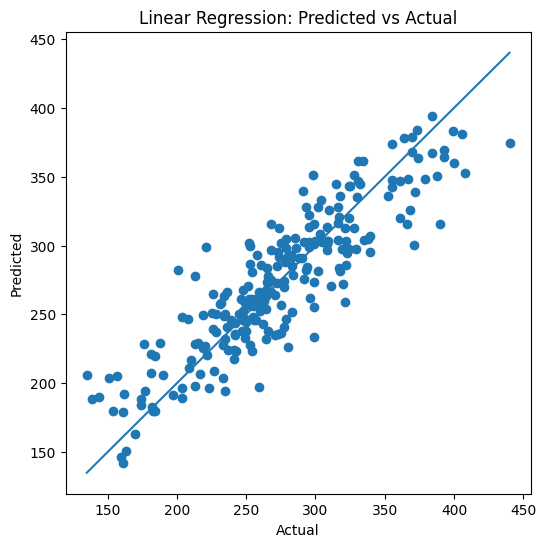

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
lr_model = LinearRegression()
rf_model = RandomForestRegressor(random_state=42)

lr_model.fit(X_train_processed, y_train)
rf_model.fit(X_train_processed, y_train)
y_pred_lr = lr_model.predict(X_test_processed)
y_pred_rf = rf_model.predict(X_test_processed)
# Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

# Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\nRandom Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.title("Linear Regression: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

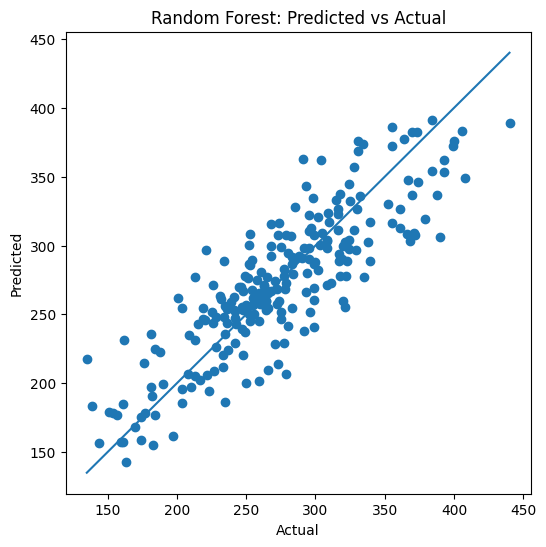

In [5]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.title("Random Forest: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

In [6]:
feature_names = preprocessor.get_feature_names_out()

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(5)

,feature,importance
13,num__is_festival,0.173473
10,cat__store_size_small,0.167683
7,cat__location_type_urban,0.108378
17,num__day_of_week,0.086316
12,num__is_weekend,0.061208


### Model Evaluation Summary

- The Random Forest model performs better than Linear Regression, as it achieves lower RMSE and MAE values.
- The parity plot for Random Forest shows predictions closer to the diagonal line, indicating better accuracy.
- Linear Regression shows more spread, suggesting it may not capture complex patterns in the data.

### Feature Importance

The top important features identified by the Random Forest model include key factors such as store characteristics, promotions, and competition density.

These features have the strongest influence on predicting the number of items sold.